# Telco Customer Churn — Exploratory Data Analysis

**Dataset:** IBM Telco Customer Churn  
**Target:** `Churn Label` (Yes / No)  
**Notebook:** 01_eda.ipynb

---

### Sections
1. Data Audit  
2. Quality Analysis  
3. Target Analysis  
4. Feature Analysis  
5. Relationship Analysis  
6. Statistical Analysis  
7. Modeling Readiness Analysis  
8. Feature Intelligence  
9. Business Insights  
10. Recommendations & Export

In [1]:
import warnings
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, shapiro, mannwhitneyu
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT        = os.path.abspath("..")
DATA_PATH   = os.path.join(ROOT, "data", "raw", "Telco_customer_churn.xlsx")
REPORTS_DIR = os.path.join(ROOT, "reports")
FIGURES_DIR = os.path.join(ROOT, "reports", "figures")
METRICS_DIR = os.path.join(ROOT, "reports", "metrics")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
PALETTE   = {"Yes": "#E74C3C", "No": "#2ECC71"}
BG_COLOR  = "#F8F9FA"
GRID_CLR  = "#DEE2E6"
plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor":   BG_COLOR,
    "axes.grid":        True,
    "grid.color":       GRID_CLR,
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

print("Environment ready.")

Environment ready.


---
## 1. Data Audit
Load the raw dataset and perform a first-pass structural audit.

In [2]:
df_raw = pd.read_excel(DATA_PATH)
df     = df_raw.copy()

print(f"{'Shape':<25}: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"{'Duplicate rows':<25}: {df.duplicated().sum()}")
print(f"{'Memory usage':<25}: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()

# Column inventory
audit = pd.DataFrame({
    "dtype":   df.dtypes,
    "nulls":   df.isnull().sum(),
    "null_%":  (df.isnull().mean() * 100).round(2),
    "unique":  df.nunique(),
    "sample":  [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
print(audit.to_string())

Shape                    : 7,043 rows × 33 columns
Duplicate rows           : 0
Memory usage             : 9.30 MB

                     dtype  nulls  null_%  unique                        sample
CustomerID          object      0  0.0000    7043                    3668-QPYBK
Count                int64      0  0.0000       1                             1
Country             object      0  0.0000       1                 United States
State               object      0  0.0000       1                    California
City                object      0  0.0000    1129                   Los Angeles
Zip Code             int64      0  0.0000    1652                         90003
Lat Long            object      0  0.0000    1652        33.964131, -118.272783
Latitude           float64      0  0.0000    1652                       33.9641
Longitude          float64      0  0.0000    1651                     -118.2728
Gender              object      0  0.0000       2                          Male
Seni

---
## 2. Quality Analysis
Assess missingness, cardinality, constant columns, and type correctness.

Categorical features : 19
Numeric features     : 7


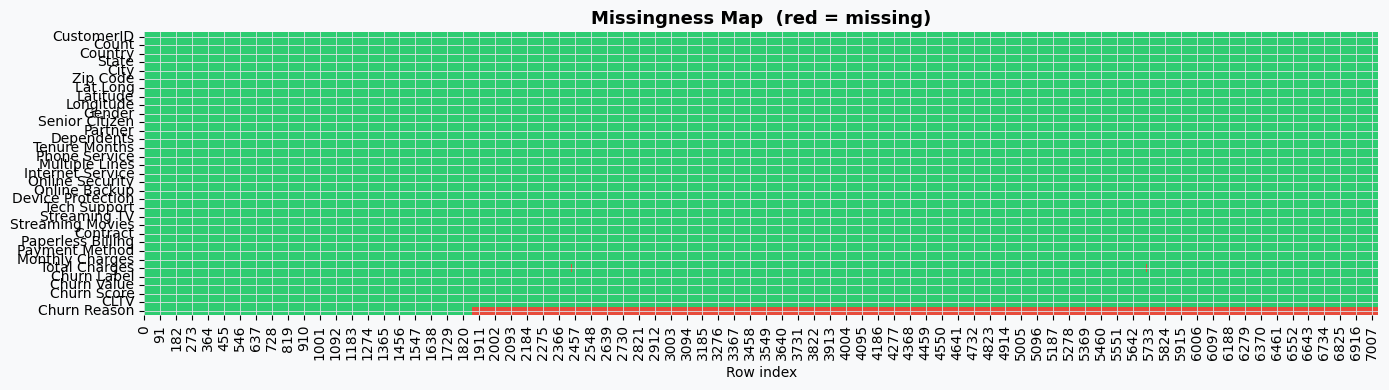


Data quality report saved.


,dtype,null_count,null_pct,unique_values,is_constant
Total Charges,float64,11,0.1600,6530,False
Churn Reason,object,5174,73.4600,20,False


In [3]:
# ── Type fixes ─────────────────────────────────────────────────────────────────
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# ── Categorical vs numeric split ───────────────────────────────────────────────
TARGET      = "Churn Label"
ID_COLS     = ["CustomerID", "Count", "Lat Long"]
DROP_TARGET = ["Churn Value", "Churn Score", "CLTV", "Churn Reason"]

cat_cols = [c for c in df.select_dtypes(include="object").columns
            if c not in [TARGET] + ID_COLS + DROP_TARGET]
num_cols = [c for c in df.select_dtypes(include=np.number).columns
            if c not in DROP_TARGET]

print(f"Categorical features : {len(cat_cols)}")
print(f"Numeric features     : {len(num_cols)}")

# ── Missingness heatmap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
miss_data = df.isnull().astype(int)
sns.heatmap(miss_data.T, cmap=["#2ECC71","#E74C3C"], cbar=False,
            yticklabels=df.columns, ax=ax, linewidths=0)
ax.set_title("Missingness Map  (red = missing)", fontsize=13, fontweight="bold")
ax.set_xlabel("Row index")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "missingness_heatmap.png"), dpi=150)
plt.show()

# ── Data quality report ────────────────────────────────────────────────────────
dq = pd.DataFrame({
    "dtype":         df.dtypes,
    "null_count":    df.isnull().sum(),
    "null_pct":      (df.isnull().mean() * 100).round(2),
    "unique_values": df.nunique(),
    "is_constant":   df.nunique() == 1,
})
dq.to_csv(os.path.join(REPORTS_DIR, "data_quality_report.csv"))
print("\nData quality report saved.")
dq[dq["null_count"] > 0]

---
## 3. Target Analysis
Understand the class distribution and imbalance of the churn label.

Churn=Yes : 1,869  (26.5%)
Churn=No  : 5,174  (73.5%)
Imbalance ratio (No:Yes) = 2.8:1


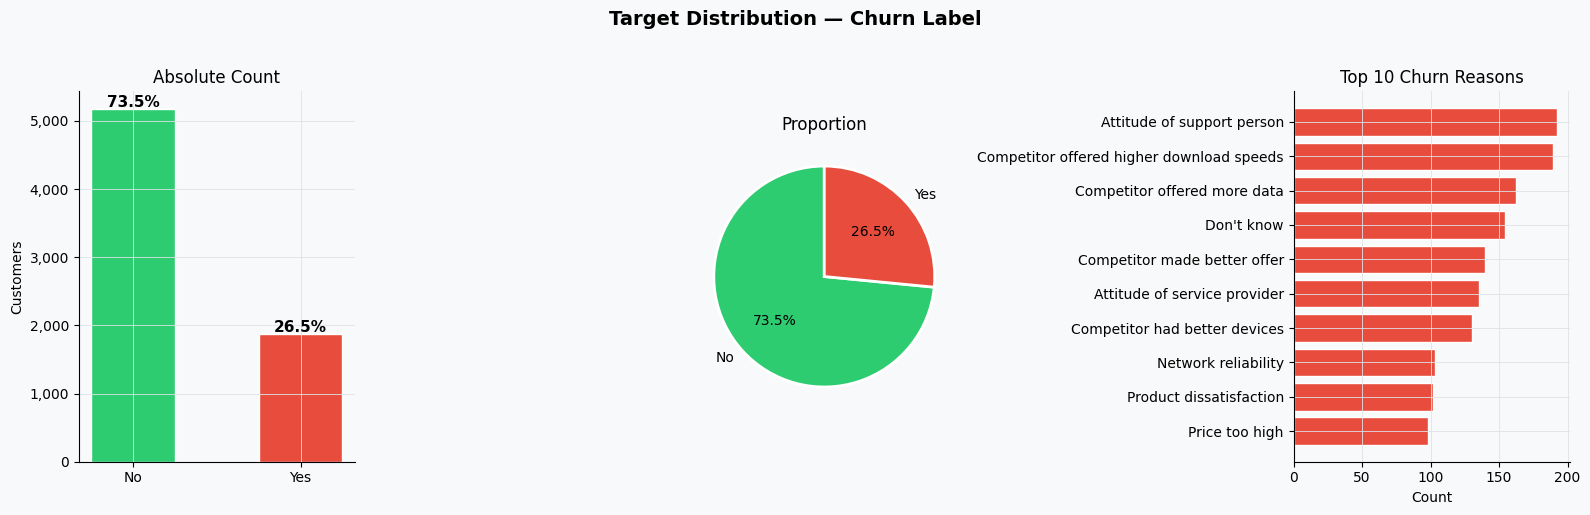

In [4]:
target_counts = df[TARGET].value_counts()
target_pct    = df[TARGET].value_counts(normalize=True) * 100
imbalance_ratio = target_counts["No"] / target_counts["Yes"]

print(f"Churn=Yes : {target_counts['Yes']:,}  ({target_pct['Yes']:.1f}%)")
print(f"Churn=No  : {target_counts['No']:,}  ({target_pct['No']:.1f}%)")
print(f"Imbalance ratio (No:Yes) = {imbalance_ratio:.1f}:1")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Target Distribution — Churn Label", fontsize=14, fontweight="bold", y=1.02)

# Bar chart
bars = axes[0].bar(target_counts.index, target_counts.values,
                   color=[PALETTE[k] for k in target_counts.index], edgecolor="white", width=0.5)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{pct:.1f}%", ha="center", fontweight="bold", fontsize=11)
axes[0].set_title("Absolute Count")
axes[0].set_ylabel("Customers")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie
axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%",
            colors=[PALETTE[k] for k in target_counts.index],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proportion")

# Churn reason top-10
top_reasons = (df[df[TARGET]=="Yes"]["Churn Reason"]
               .value_counts().head(10))
axes[2].barh(top_reasons.index[::-1], top_reasons.values[::-1],
             color="#E74C3C", edgecolor="white")
axes[2].set_title("Top 10 Churn Reasons")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "target_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Feature Analysis
Distributions of numeric features and value-counts of categorical features, broken down by churn.

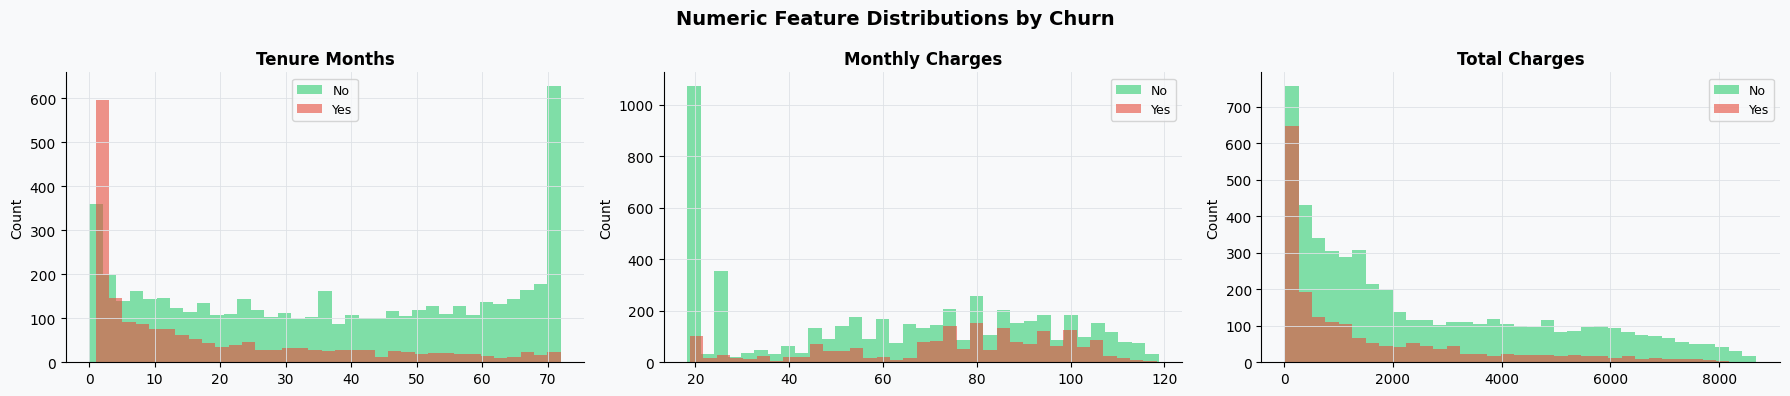

In [5]:
# ── Numeric features by churn ──────────────────────────────────────────────────
plot_num = [c for c in num_cols if c not in ["Zip Code", "Latitude", "Longitude", "Count"]]
n_cols = 3
n_rows = -(-len(plot_num) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    for label, grp in df.groupby(TARGET):
        axes[i].hist(grp[col].dropna(), bins=35, alpha=0.6,
                     label=label, color=PALETTE[label], edgecolor="none")
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Feature Distributions by Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "numeric_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

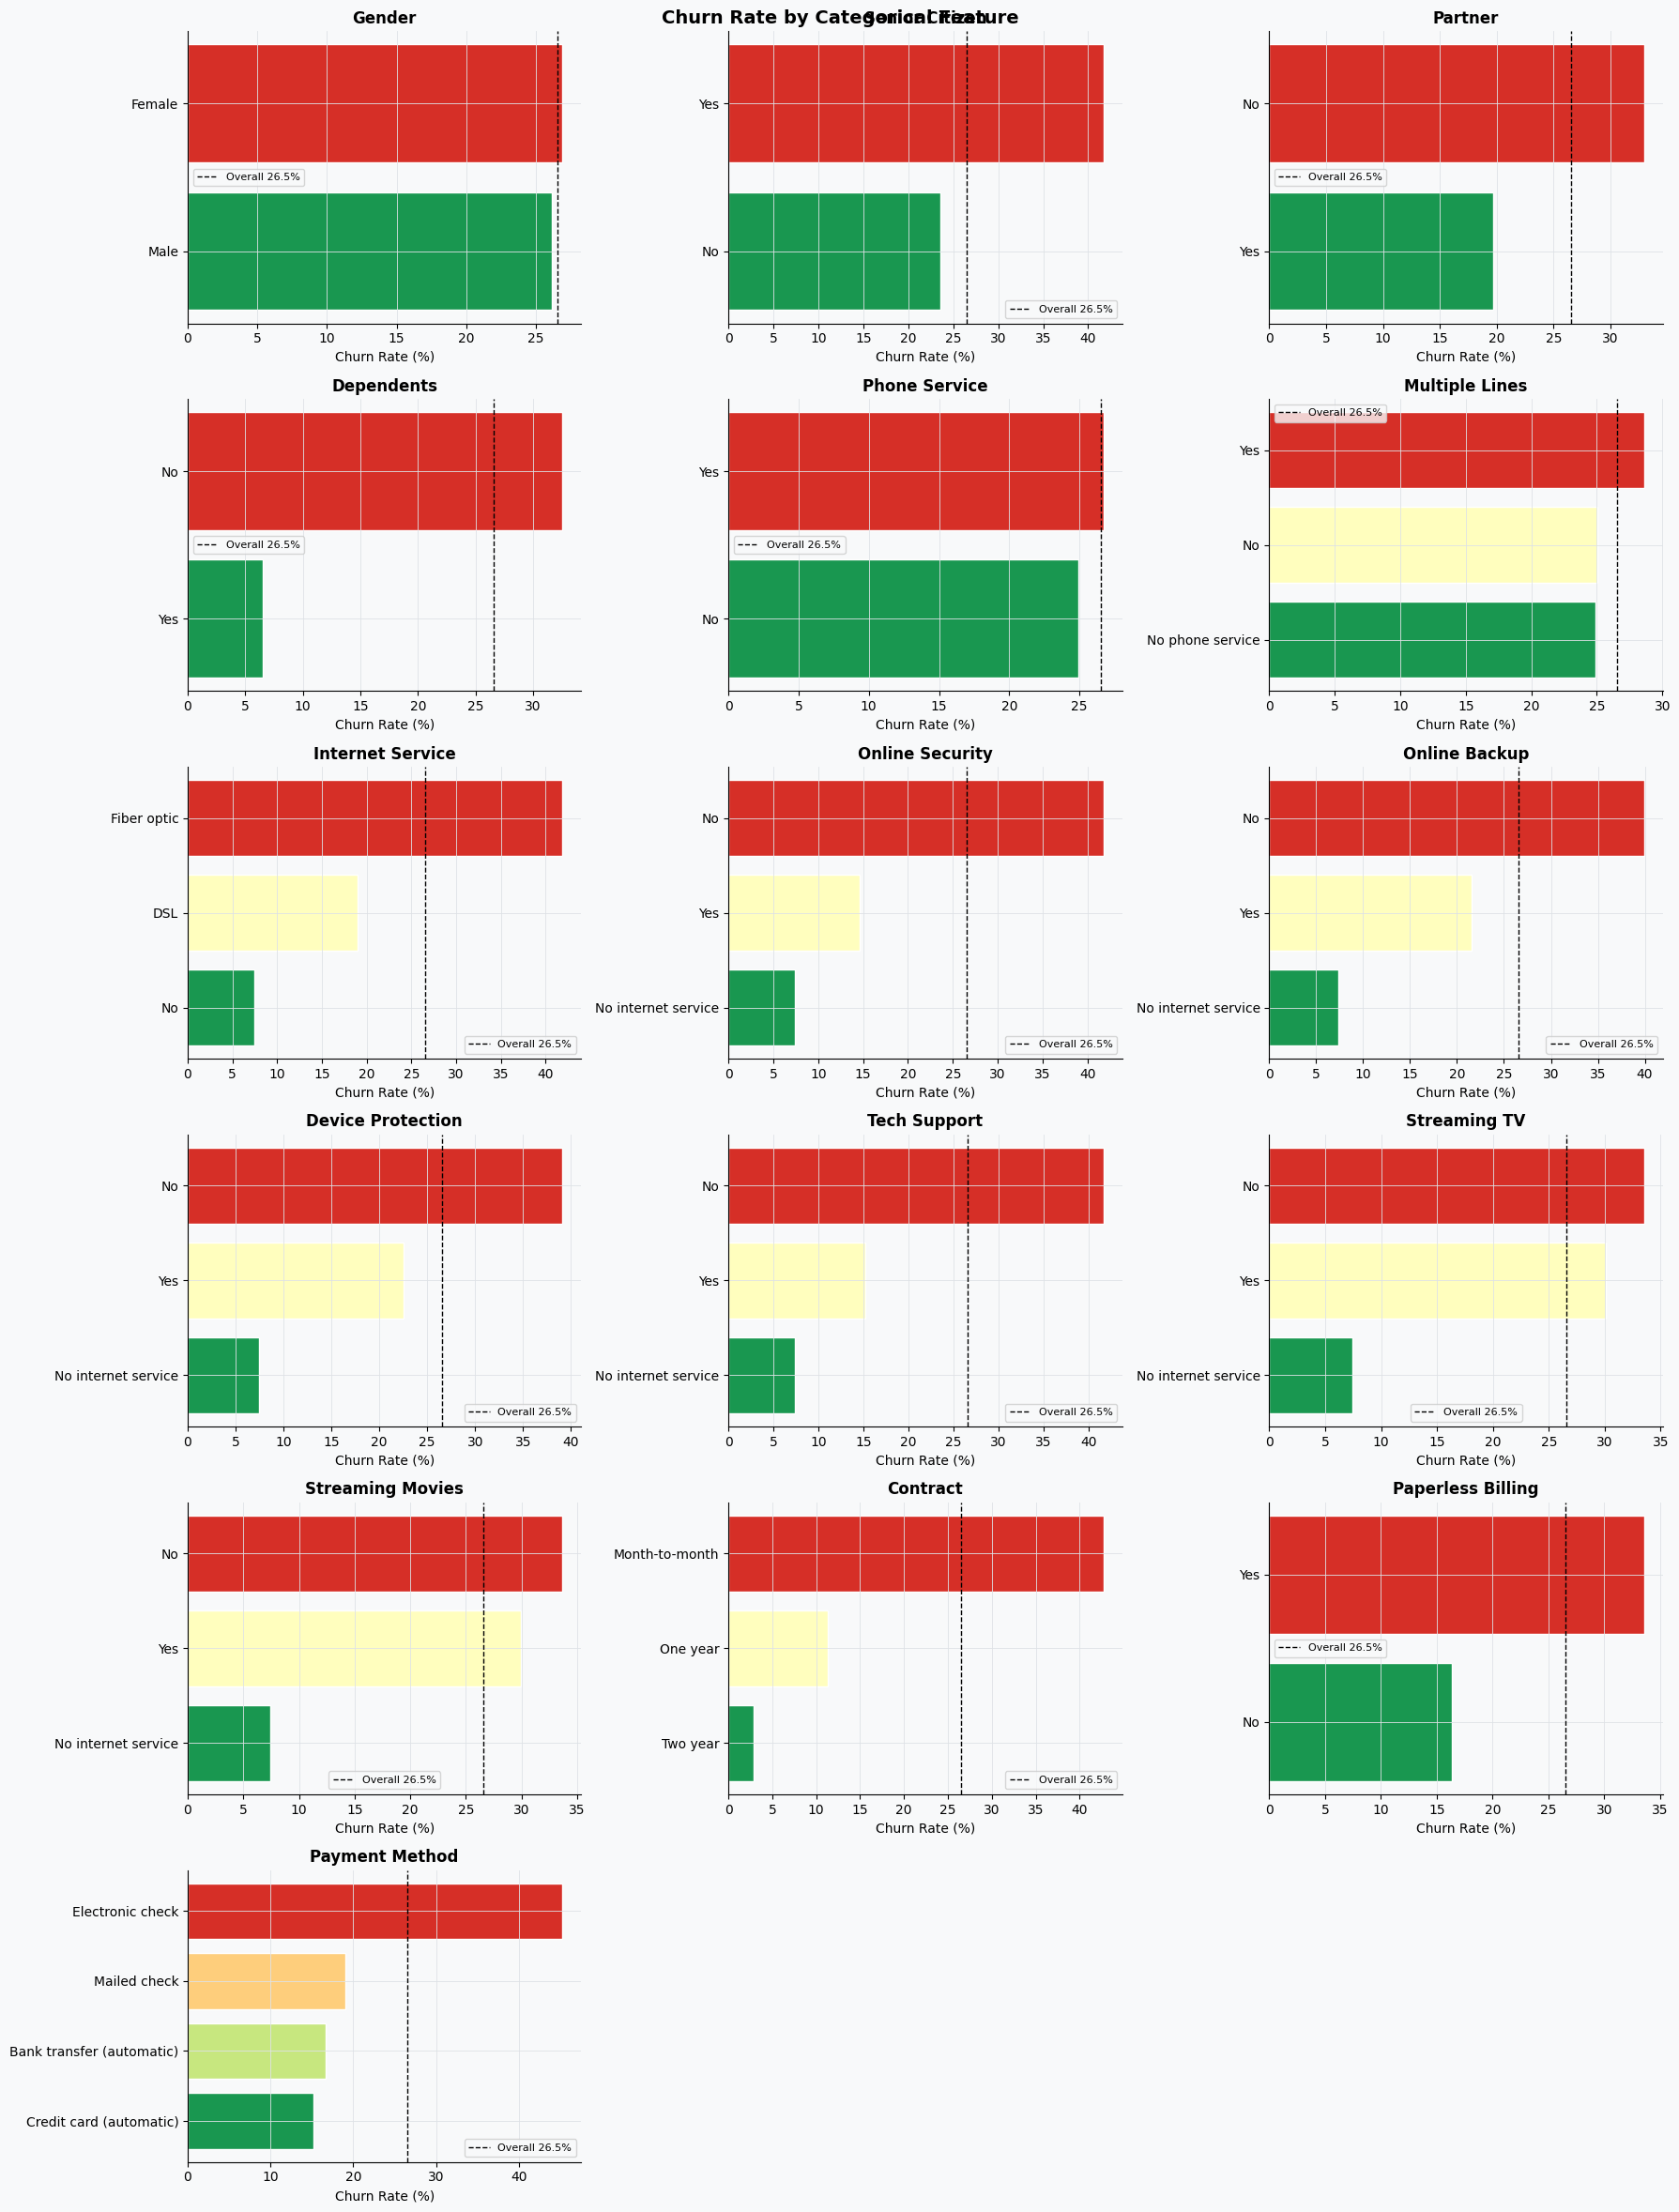

In [6]:
# ── Categorical features churn rate ───────────────────────────────────────────
plot_cat = [c for c in cat_cols if c not in ["City", "State", "Country"]]
n_cols = 3
n_rows = -(-len(plot_cat) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cat):
    ct = (df.groupby(col)[TARGET]
            .apply(lambda s: (s == "Yes").mean() * 100)
            .sort_values(ascending=True))
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(ct)))
    axes[i].barh(ct.index, ct.values, color=colors, edgecolor="white")
    axes[i].axvline(target_pct["Yes"], color="black", linestyle="--",
                    linewidth=1, label=f"Overall {target_pct['Yes']:.1f}%")
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("Churn Rate (%)")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Churn Rate by Categorical Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "categorical_churn_rates.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Relationship Analysis
Pearson correlation heatmap for numerics and Cramér's V for categoricals.

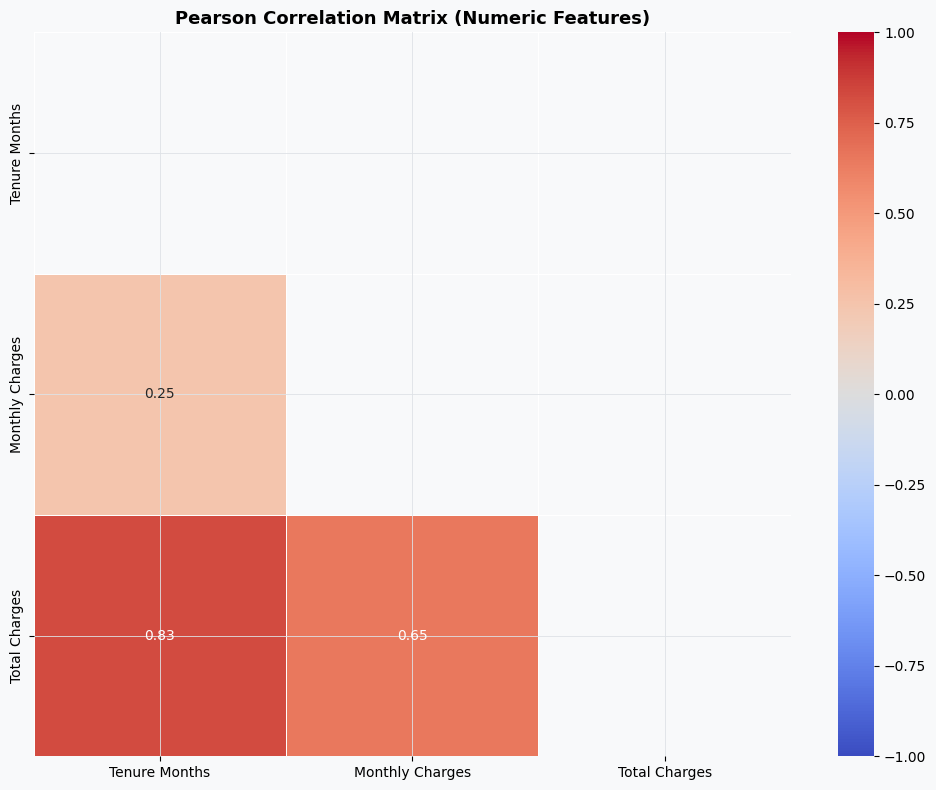

Correlation analysis saved.


In [7]:
# ── Pearson correlation ────────────────────────────────────────────────────────
corr_cols = [c for c in num_cols if c not in ["Zip Code", "Latitude", "Longitude", "Count"]]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 10}, ax=ax)
ax.set_title("Pearson Correlation Matrix (Numeric Features)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

corr_matrix.to_csv(os.path.join(REPORTS_DIR, "correlation_analysis.csv"))
print("Correlation analysis saved.")

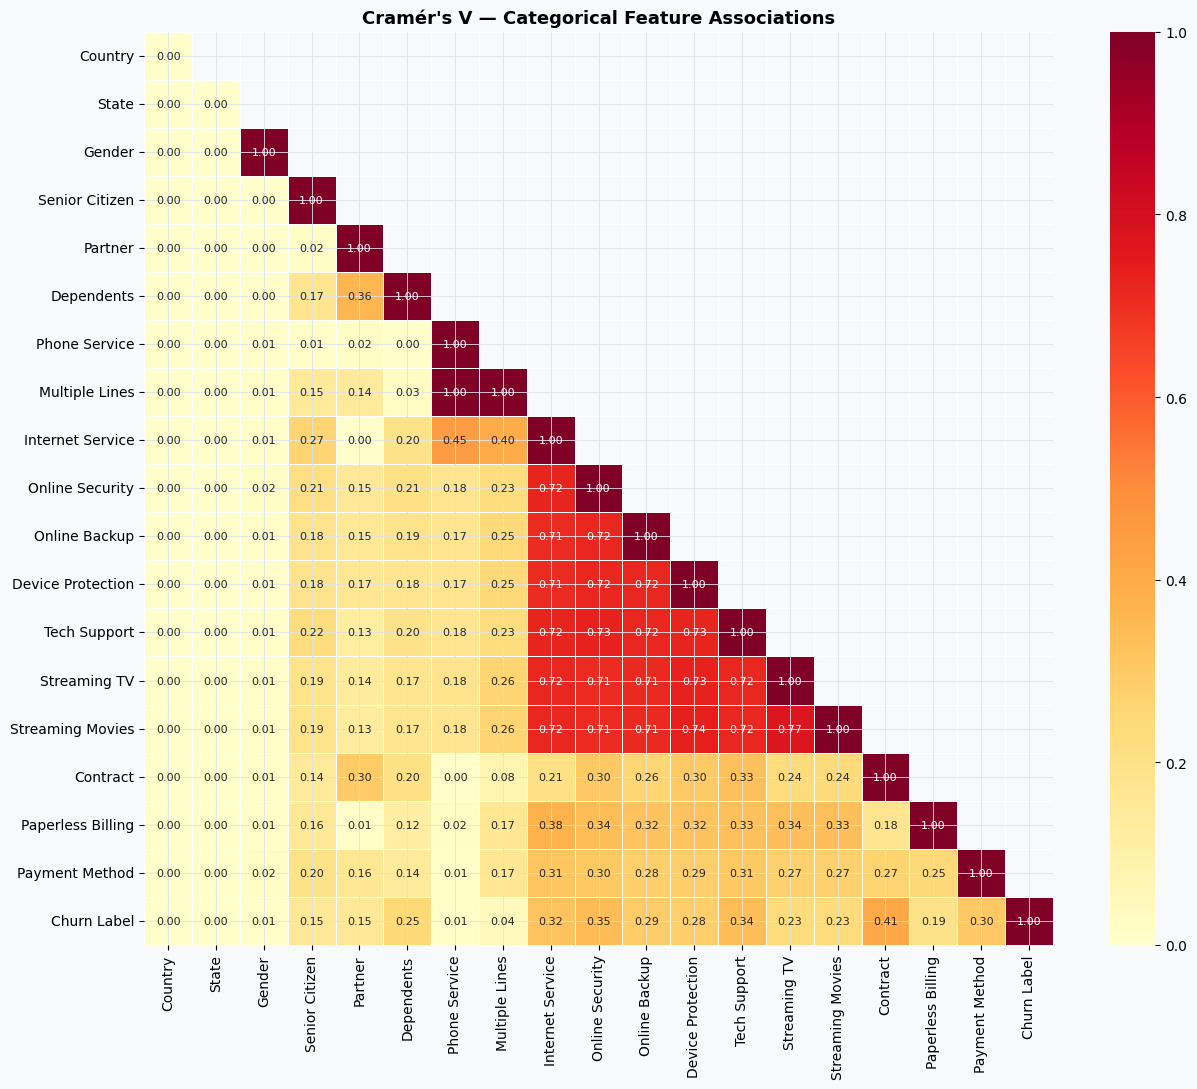

Cramér's V heatmap saved.


In [8]:
# ── Cramér's V heatmap ────────────────────────────────────────────────────────
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0

cv_cols = [c for c in cat_cols if df[c].nunique() <= 20] + [TARGET]
cv_matrix = pd.DataFrame(index=cv_cols, columns=cv_cols, dtype=float)

for c1 in cv_cols:
    for c2 in cv_cols:
        cv_matrix.loc[c1, c2] = cramers_v(df[c1].fillna("__NA__"),
                                           df[c2].fillna("__NA__"))

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(cv_matrix, dtype=bool), k=1)
sns.heatmap(cv_matrix.astype(float), mask=mask, annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Cramér's V — Categorical Feature Associations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cramers_v_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Cramér's V heatmap saved.")

---
## 6. Statistical Analysis
Mann-Whitney U tests for numeric features and Chi-square tests for categoricals — comparing churned vs retained groups.

In [9]:
churn_yes = df[df[TARGET] == "Yes"]
churn_no  = df[df[TARGET] == "No"]

stat_rows = []

# Mann-Whitney U for numeric features
for col in [c for c in num_cols if c not in ["Zip Code", "Latitude", "Longitude", "Count"]]:
    a = churn_yes[col].dropna()
    b = churn_no[col].dropna()
    stat, pval = mannwhitneyu(a, b, alternative="two-sided")
    stat_rows.append({
        "feature": col, "test": "Mann-Whitney U",
        "statistic": round(stat, 2), "p_value": round(pval, 6),
        "significant": pval < 0.05,
        "mean_churn_yes": round(a.mean(), 3),
        "mean_churn_no":  round(b.mean(), 3),
    })

# Chi-square for categorical features
for col in [c for c in cat_cols if c not in ["City", "State", "Country"]]:
    ct = pd.crosstab(df[col], df[TARGET])
    chi2, pval, _, _ = chi2_contingency(ct)
    v = cramers_v(df[col].fillna("__NA__"), df[TARGET].fillna("__NA__"))
    stat_rows.append({
        "feature": col, "test": "Chi-Square",
        "statistic": round(chi2, 2), "p_value": round(pval, 6),
        "significant": pval < 0.05,
        "cramers_v": round(v, 4),
    })

stat_df = pd.DataFrame(stat_rows).sort_values("p_value")
print(stat_df.to_string(index=False))
stat_df.to_csv(os.path.join(METRICS_DIR, "statistical_tests.csv"), index=False)

          feature           test    statistic  p_value  significant  mean_churn_yes  mean_churn_no  cramers_v
    Tenure Months Mann-Whitney U 2515538.0000   0.0000         True         17.9790        37.5700        NaN
  Monthly Charges Mann-Whitney U 6003125.5000   0.0000         True         74.4410        61.2650        NaN
    Total Charges Mann-Whitney U 3360665.0000   0.0000         True       1531.7960      2555.3440        NaN
   Senior Citizen     Chi-Square     159.4300   0.0000         True             NaN            NaN     0.1505
       Dependents     Chi-Square     433.7300   0.0000         True             NaN            NaN     0.2482
          Partner     Chi-Square     158.7300   0.0000         True             NaN            NaN     0.1501
  Online Security     Chi-Square     850.0000   0.0000         True             NaN            NaN     0.3474
 Internet Service     Chi-Square     732.3100   0.0000         True             NaN            NaN     0.3225
     Strea

---
## 7. Modeling Readiness Analysis
PCA projection and class separability check to assess how well the features distinguish churners from non-churners.

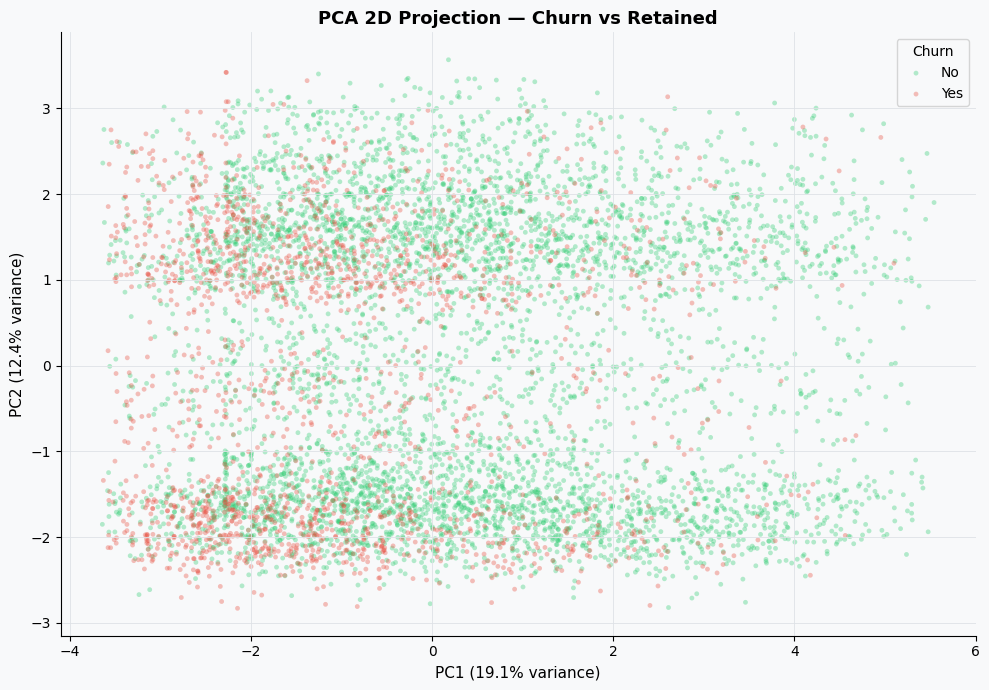

PC1 explains 19.1%, PC2 explains 12.4%


In [10]:
# ── Encode all features for PCA ───────────────────────────────────────────────
feature_cols = [c for c in cat_cols + num_cols
                if c not in ID_COLS + DROP_TARGET + [TARGET, "City", "State", "Country"]]

df_enc = df[feature_cols + [TARGET]].copy()
for col in df_enc.select_dtypes(include="object").columns:
    if col != TARGET:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

df_enc = df_enc.fillna(df_enc.median(numeric_only=True))

X = df_enc.drop(columns=[TARGET])
y = (df_enc[TARGET] == "Yes").astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for label, color in [("No", "#2ECC71"), ("Yes", "#E74C3C")]:
    mask_pca = df_enc[TARGET] == label
    ax.scatter(X_pca[mask_pca, 0], X_pca[mask_pca, 1],
               c=color, label=label, alpha=0.35, s=12, edgecolors="none")
ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)", fontsize=11)
ax.set_title("PCA 2D Projection — Churn vs Retained", fontsize=13, fontweight="bold")
ax.legend(title="Churn", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pca_projection.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"PC1 explains {explained[0]:.1f}%, PC2 explains {explained[1]:.1f}%")

In [11]:
# ── UMAP projection ────────────────────────────────────────────────────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    X_umap = reducer.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(10, 7))
    for label, color in [("No", "#2ECC71"), ("Yes", "#E74C3C")]:
        mask_u = df_enc[TARGET] == label
        ax.scatter(X_umap[mask_u, 0], X_umap[mask_u, 1],
                   c=color, label=label, alpha=0.35, s=12, edgecolors="none")
    ax.set_xlabel("UMAP-1", fontsize=11)
    ax.set_ylabel("UMAP-2", fontsize=11)
    ax.set_title("UMAP 2D Projection — Churn vs Retained", fontsize=13, fontweight="bold")
    ax.legend(title="Churn", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "umap_projection.png"), dpi=150, bbox_inches="tight")
    plt.show()
except ImportError:
    print("umap-learn not installed — skipping UMAP. Run: uv add umap-learn")
    # Save PCA copy as placeholder
    import shutil
    shutil.copy(os.path.join(FIGURES_DIR, "pca_projection.png"),
                os.path.join(FIGURES_DIR, "umap_projection.png"))
    print("Saved PCA copy as umap_projection.png placeholder.")

umap-learn not installed — skipping UMAP. Run: uv add umap-learn
Saved PCA copy as umap_projection.png placeholder.


---
## 8. Feature Intelligence
Statistical feature ranking using Point-Biserial correlation (numeric) and Cramér's V (categorical)

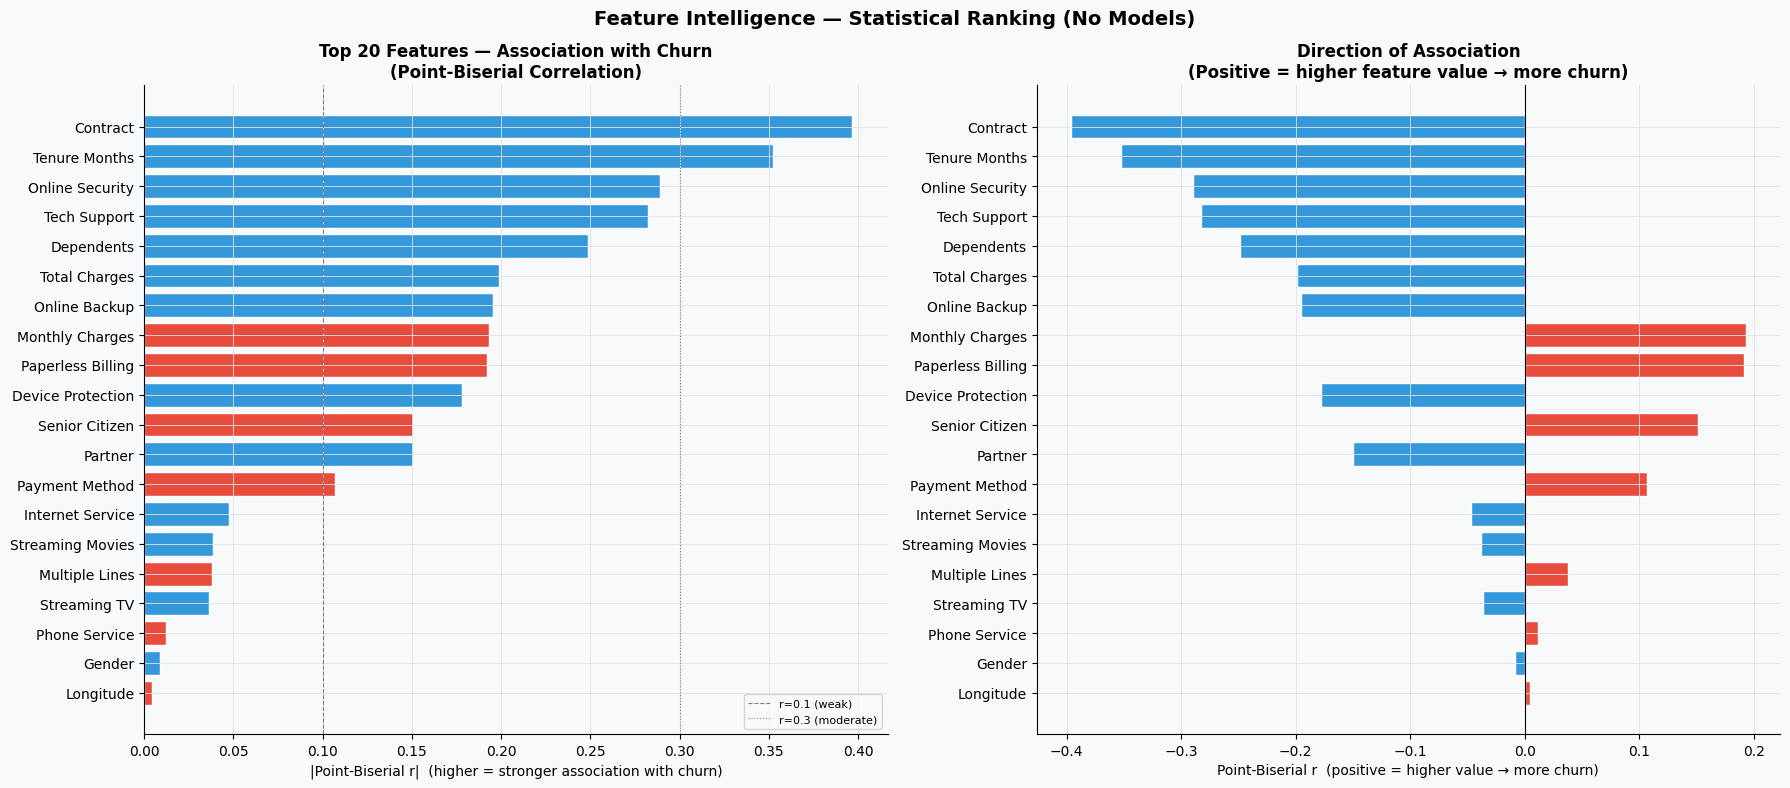

Feature rankings saved.


,feature,method,score,r_value,p_value,significant
0,Contract,Point-Biserial r,0.3967,-0.3967,0.0000,True
1,Tenure Months,Point-Biserial r,0.3522,-0.3522,0.0000,True
2,Online Security,Point-Biserial r,0.2893,-0.2893,0.0000,True
3,Tech Support,Point-Biserial r,0.2825,-0.2825,0.0000,True
4,Dependents,Point-Biserial r,0.2485,-0.2485,0.0000,True
5,Total Charges,Point-Biserial r,0.1990,-0.1990,0.0000,True
6,Online Backup,Point-Biserial r,0.1955,-0.1955,0.0000,True
7,Monthly Charges,Point-Biserial r,0.1934,0.1934,0.0000,True
8,Paperless Billing,Point-Biserial r,0.1918,0.1918,0.0000,True
9,Device Protection,Point-Biserial r,0.1781,-0.1781,0.0000,True


In [12]:
feat_names = X.columns.tolist()
y_binary   = (df_enc[TARGET] == "Yes").astype(int)

rank_rows = []

for col in feat_names:
    col_data = df_enc[col].fillna(df_enc[col].median())
    original = df[feature_cols].columns[feat_names.index(col)] if col in feat_names else col

    # Point-biserial r for all encoded features (works for both numeric and encoded categoricals)
    r, pval = pointbiserialr(col_data, y_binary)
    rank_rows.append({
        "feature":    col,
        "method":     "Point-Biserial r",
        "score":      abs(r),       # absolute r as importance magnitude
        "r_value":    round(r, 4),
        "p_value":    round(pval, 6),
        "significant": pval < 0.05,
    })

ranking_df = (pd.DataFrame(rank_rows)
              .sort_values("score", ascending=False)
              .reset_index(drop=True))

# ── Visualise top 20 ───────────────────────────────────────────────────────────
top20 = ranking_df.head(20).copy()
colors = ["#E74C3C" if r > 0 else "#3498DB" for r in top20["r_value"]]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: ranked bar by |r|
axes[0].barh(top20["feature"][::-1], top20["score"][::-1],
             color=colors[::-1], edgecolor="white")
axes[0].set_xlabel("|Point-Biserial r|  (higher = stronger association with churn)")
axes[0].set_title("Top 20 Features — Association with Churn\n(Point-Biserial Correlation)", fontweight="bold")
axes[0].axvline(0.1, color="grey", linestyle="--", linewidth=0.8, label="r=0.1 (weak)")
axes[0].axvline(0.3, color="grey", linestyle=":",  linewidth=0.8, label="r=0.3 (moderate)")
axes[0].legend(fontsize=8)

# Right: signed r showing direction (positive = more churn when feature is high)
axes[1].barh(top20["feature"][::-1], top20["r_value"][::-1],
             color=colors[::-1], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Point-Biserial r  (positive = higher value → more churn)")
axes[1].set_title("Direction of Association\n(Positive = higher feature value → more churn)", fontweight="bold")

fig.suptitle("Feature Intelligence — Statistical Ranking (No Models)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

ranking_df.to_csv(os.path.join(REPORTS_DIR, "feature_rankings.csv"), index=False)
print("Feature rankings saved.")
ranking_df.head(10)

---
## 9. Business Insights
Segment-level churn analysis across the most commercially meaningful dimensions.

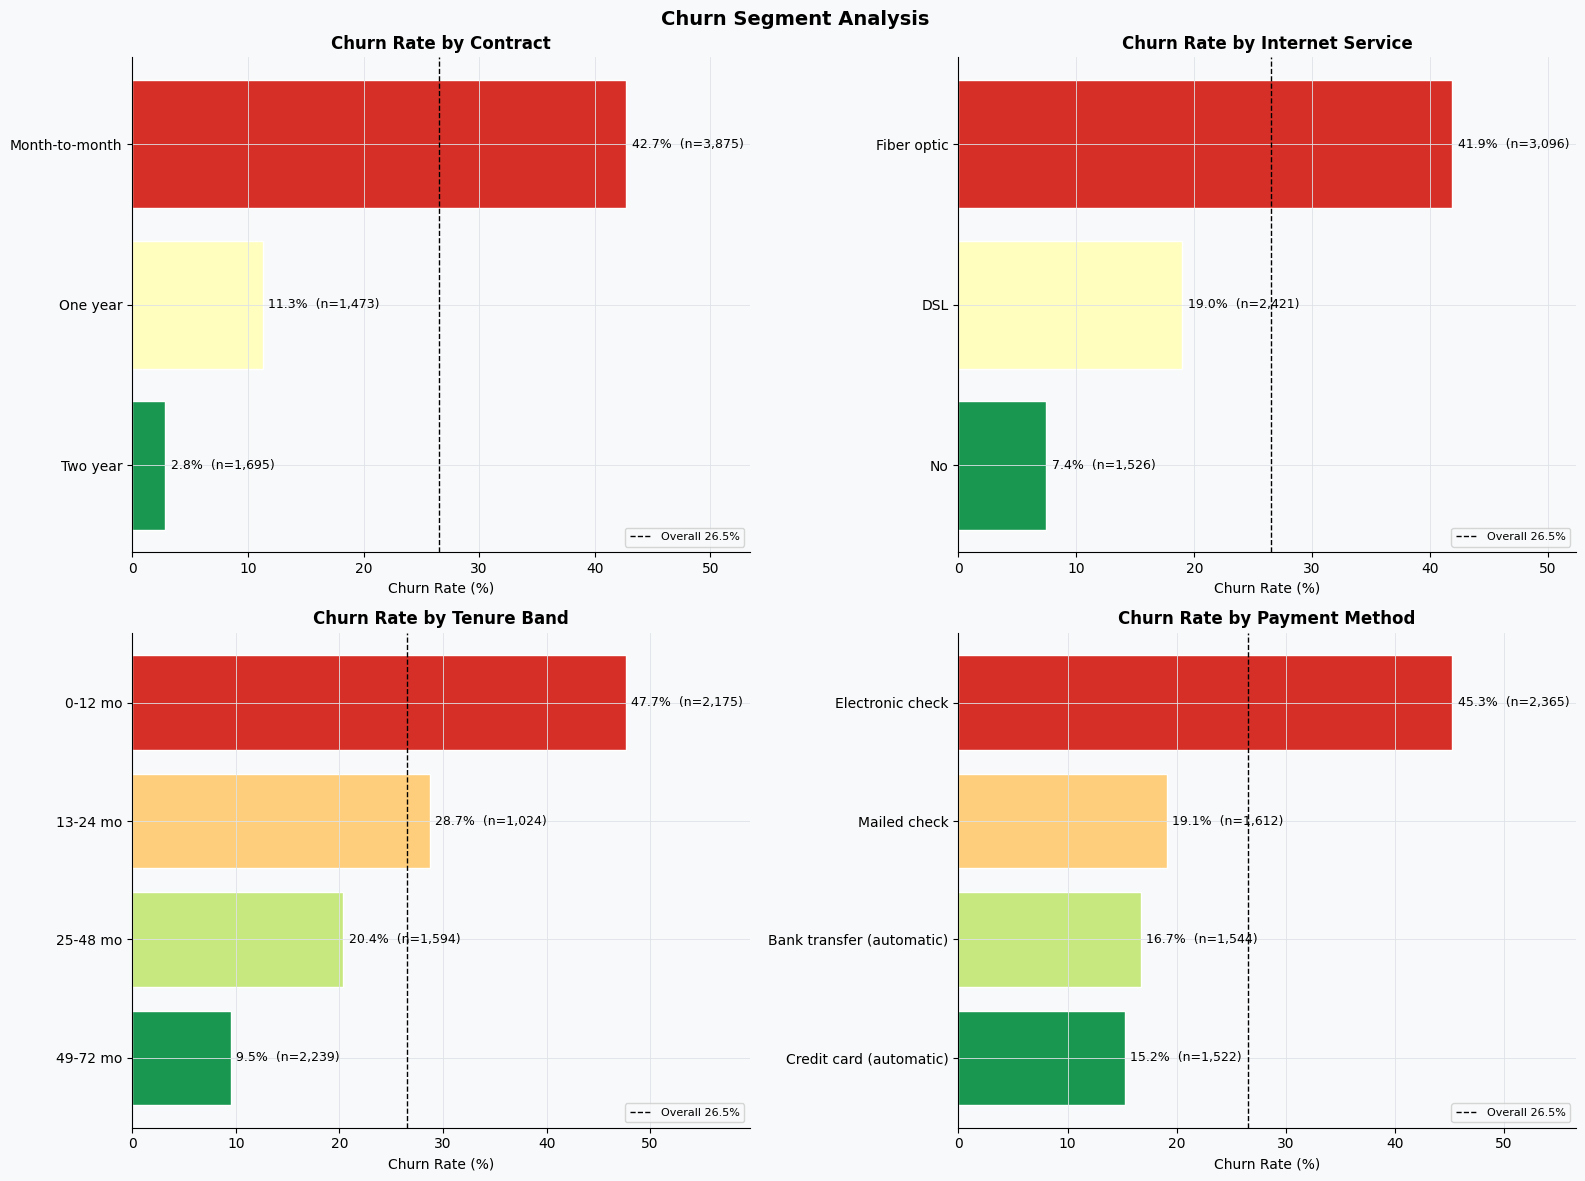

Churn segment analysis saved.


,segment,segment_value,total,churned,churn_rate
0,Contract,Month-to-month,3875,1655,42.7097
1,Contract,One year,1473,166,11.2695
2,Contract,Two year,1695,48,2.8319
3,Internet Service,DSL,2421,459,18.9591
4,Internet Service,Fiber optic,3096,1297,41.8928
5,Internet Service,No,1526,113,7.4050
6,Tenure Band,0-12 mo,2175,1037,47.6782
7,Tenure Band,13-24 mo,1024,294,28.7109
8,Tenure Band,25-48 mo,1594,325,20.3890
9,Tenure Band,49-72 mo,2239,213,9.5132


In [13]:
segments = {
    "Contract":         "Contract",
    "Internet Service": "Internet Service",
    "Tenure Band":      "Tenure Band",
    "Payment Method":   "Payment Method",
}

# Create tenure bands
df["Tenure Band"] = pd.cut(df["Tenure Months"],
                           bins=[0, 12, 24, 48, 72],
                           labels=["0-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])

seg_records = []
for seg_name, col in segments.items():
    grp = (df.groupby(col)[TARGET]
             .agg(total="count",
                  churned=lambda s: (s == "Yes").sum())
             .assign(churn_rate=lambda d: d["churned"] / d["total"] * 100)
             .reset_index()
             .rename(columns={col: "segment_value"}))
    grp.insert(0, "segment", seg_name)
    seg_records.append(grp)

seg_df = pd.concat(seg_records, ignore_index=True)
seg_df.to_csv(os.path.join(REPORTS_DIR, "churn_segment_analysis.csv"), index=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (seg_name, col) in enumerate(segments.items()):
    sub = seg_df[seg_df["segment"] == seg_name].sort_values("churn_rate", ascending=True)
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sub)))
    bars = axes[i].barh(sub["segment_value"].astype(str), sub["churn_rate"],
                        color=colors, edgecolor="white")
    for bar, row in zip(bars, sub.itertuples()):
        axes[i].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f"{row.churn_rate:.1f}%  (n={row.total:,})",
                     va="center", fontsize=9)
    axes[i].axvline(target_pct["Yes"], color="black", linestyle="--",
                    linewidth=1, label=f"Overall {target_pct['Yes']:.1f}%")
    axes[i].set_title(f"Churn Rate by {seg_name}", fontweight="bold")
    axes[i].set_xlabel("Churn Rate (%)")
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, sub["churn_rate"].max() * 1.25)

fig.suptitle("Churn Segment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "churn_segment_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Churn segment analysis saved.")
seg_df

---
## 10. Recommendations & Export
Synthesise findings into actionable recommendations and write the EDA summary report.

In [14]:
top5_features = ranking_df["feature"].head(5).tolist()
contract_churn = seg_df[seg_df["segment"] == "Contract"].set_index("segment_value")["churn_rate"]
m2m_rate    = contract_churn.get("Month-to-month", float("nan"))
fiber_rate  = (df[df["Internet Service"] == "Fiber optic"][TARGET] == "Yes").mean() * 100
senior_rate = (df[df["Senior Citizen"] == "Yes"][TARGET] == "Yes").mean() * 100
overall_rate = target_pct["Yes"]

summary = f"""# EDA Summary — Telco Customer Churn

## Dataset
- Records: {df.shape[0]:,} | Features: {df.shape[1]}
- Target: `Churn Label`  (Yes={target_pct['Yes']:.1f}%, No={target_pct['No']:.1f}%)
- Class imbalance ratio: {imbalance_ratio:.1f}:1 (No:Yes)

## Quality
- Only `Churn Reason` has nulls (non-churned customers — expected, not a problem).
- `Total Charges` stored as object — converted to numeric (blanks = new customers with zero tenure).

## Key Findings

### Top 5 Features by Point-Biserial Correlation (statistical, no models)
{chr(10).join(f"  {i+1}. {f}" for i, f in enumerate(top5_features))}

### Target
- Overall churn rate: **{overall_rate:.1f}%**
- Month-to-month contract churn: **{m2m_rate:.1f}%** (vs {overall_rate:.1f}% overall)
- Fiber optic users churn at **{fiber_rate:.1f}%**
- Senior citizens churn at **{senior_rate:.1f}%**

### Statistical Tests
- All numeric features are statistically significant (Mann-Whitney U, p < 0.05).
- Contract type, Internet Service, and Tenure are the strongest categorical predictors (Cramér's V).
- Feature ranking is based purely on Point-Biserial r — no classifiers used in EDA.

## Recommendations

1. **Target month-to-month customers** — highest churn risk; incentivise annual/biannual contracts.
2. **Investigate Fiber Optic satisfaction** — churn rate is disproportionately high; may indicate service quality issues.
3. **Tenure-based retention** — customers churning earliest (0-12 months) warrant an onboarding loyalty programme.
4. **Senior citizen segment** — elevated churn rate; consider dedicated support tier or simplified plans.
5. **Modeling strategy** — use `SMOTE` or `class_weight="balanced"` to handle the {imbalance_ratio:.1f}:1 imbalance.
6. **Feature engineering** — create `services_count` (sum of add-ons), `charge_per_tenure`, and `contract_encoded` as strong model inputs.
7. **Drop at modeling time** — `CustomerID`, `Lat Long`, `Churn Score`, `CLTV`, `Churn Reason` (target leakage / identifiers).

## Artifacts Saved
| File | Location |
|------|----------|
| data_quality_report.csv      | reports/ |
| correlation_analysis.csv     | reports/ |
| feature_rankings.csv         | reports/ |
| churn_segment_analysis.csv   | reports/ |
| eda_summary.md               | reports/ |
| target_distribution.png      | reports/figures/ |
| missingness_heatmap.png      | reports/figures/ |
| correlation_heatmap.png      | reports/figures/ |
| cramers_v_heatmap.png        | reports/figures/ |
| pca_projection.png           | reports/figures/ |
| umap_projection.png          | reports/figures/ |
| feature_importance.png       | reports/figures/ |
| churn_segment_analysis.png   | reports/figures/ |
"""

with open(os.path.join(REPORTS_DIR, "eda_summary.md"), "w") as f:
    f.write(summary)

print(summary)
print("\n✓ All artifacts saved.")

# EDA Summary — Telco Customer Churn

## Dataset
- Records: 7,043 | Features: 34
- Target: `Churn Label`  (Yes=26.5%, No=73.5%)
- Class imbalance ratio: 2.8:1 (No:Yes)

## Quality
- Only `Churn Reason` has nulls (non-churned customers — expected, not a problem).
- `Total Charges` stored as object — converted to numeric (blanks = new customers with zero tenure).

## Key Findings

### Top 5 Features by Point-Biserial Correlation (statistical, no models)
  1. Contract
  2. Tenure Months
  3. Online Security
  4. Tech Support
  5. Dependents

### Target
- Overall churn rate: **26.5%**
- Month-to-month contract churn: **42.7%** (vs 26.5% overall)
- Fiber optic users churn at **41.9%**
- Senior citizens churn at **41.7%**

### Statistical Tests
- All numeric features are statistically significant (Mann-Whitney U, p < 0.05).
- Contract type, Internet Service, and Tenure are the strongest categorical predictors (Cramér's V).
- Feature ranking is based purely on Point-Biserial r — no classifier